## ISIC 2018 End-to-End Pipeline: Lesion Segmentation + Disease Classification

Chains Mask R-CNN (Task 1 segmentation) with EfficientNet-B0 (Task 3
classification) into a single inference pipeline.
For each image:
   1. Mask R-CNN localises the lesion and produces a binary mask.
   2. The predicted bounding box crops the lesion region.
   3. EfficientNet-B0 classifies the crop into one of 7 HAM10000 disease classes.

**Joint evaluation on 50 validation images**:
   - Mean thresholded Jaccard (T=0.65): segmentation quality
   - Balanced accuracy: classification quality over detected images
   - Combined score: arithmetic mean of the two

**Datasets required**:
   - tschandl/isic2018-challenge-task1-data-segmentation (images + masks)
   - kmader/skin-cancer-mnist-ham10000 (metadata CSV for class labels)

**Checkpoints required (add as Kaggle dataset inputs)**:
   - best_maskrcnn_isic2018.pth (Task 1 notebook output)
   - best_efficientnet_b0_run5_ham10000.pth (Task 3 notebook output)

Reference: Codella et al., arXiv:1902.03368, 2019.

## 1. Imports and configuration

In [1]:
import random
from dataclasses import dataclass
from pathlib import Path
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data
import torchvision.transforms.v2.functional as TF
import timm
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from PIL import Image
from sklearn.metrics import balanced_accuracy_score
import matplotlib.pyplot as plt

In [2]:
import os
print(os.listdir("/kaggle/input"))

['notebooks', 'datasets']


In [4]:
def show_tree(path, depth=3, current=0):
    if current >= depth:
        return
    try:
        for item in sorted(os.listdir(path)):
            print("  " * current + item)
            full = os.path.join(path, item)
            if os.path.isdir(full):
                show_tree(full, depth, current + 1)
    except PermissionError:
        pass

show_tree("/kaggle/input", depth=4)

datasets
  kmader
    skin-cancer-mnist-ham10000
      HAM10000_images_part_1
      HAM10000_images_part_2
      HAM10000_metadata.csv
      ham10000_images_part_1
      ham10000_images_part_2
      hmnist_28_28_L.csv
      hmnist_28_28_RGB.csv
      hmnist_8_8_L.csv
      hmnist_8_8_RGB.csv
  tschandl
    isic2018-challenge-task1-data-segmentation
      ISIC2018_Task1-2_Test_Input
      ISIC2018_Task1-2_Training_Input
      ISIC2018_Task1-2_Validation_Input
      ISIC2018_Task1_Training_GroundTruth
notebooks
  mendelowitzadi
    isic2018-task1-segmentation
      .virtual_documents
      __notebook__.ipynb
      __output__.json
      __results__.html
      __results___files
      checkpoints
      custom.css
      segmentation_examples_task1.png
      training_curves.png
    isic2018-task3-classification
      .virtual_documents
      __notebook__.ipynb
      __output__.json
      __results__.html
      __results___files
      b0_vs_b3_curves.png
      checkpoints
      confusion_matri

In [3]:
task1_img_dir  = Path("/kaggle/input/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input")
task1_mask_dir = Path("/kaggle/input/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1_Training_GroundTruth")
meta_path      = Path("/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv")

all_task1_ids = sorted(p.stem for p in task1_img_dir.glob("*.jpg"))
meta = pd.read_csv(meta_path)[["image_id", "dx"]].drop_duplicates("image_id")
meta_ids = set(meta["image_id"])
task1_ids = set(all_task1_ids)
matched = task1_ids & meta_ids

print(f"Task 1 training images: {len(task1_ids)}")
print(f"HAM10000 metadata:      {len(meta_ids)}")
print(f"Matched:                {len(matched)}")
print(f"First 5 Task 1 IDs:     {sorted(task1_ids)[:5]}")
print(f"First 5 matched IDs:    {sorted(matched)[:5]}")


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv'

In [5]:
# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
TASK1_BASE = Path("/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation")
TASK3_BASE = Path("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000")
CKPT_SEG   = Path("/kaggle/input/notebooks/mendelowitzadi/isic2018-task1-segmentation/checkpoints/best_maskrcnn_isic2018.pth")
CKPT_CLS   = Path("/kaggle/input/notebooks/mendelowitzadi/isic2018-task3-classification/checkpoints/best_efficientnet_b0_run5_ham10000.pth")

CFG = {
    "img_dir": TASK1_BASE / "ISIC2018_Task1-2_Training_Input",
    "mask_dir": TASK1_BASE / "ISIC2018_Task1_Training_GroundTruth",
    "metadata": TASK3_BASE / "HAM10000_metadata.csv",
    "img_size": 512,
    "cls_img_size": 224,
    "val_fraction": 0.2,
    "seed": 42,
    "n_eval": 50,  # number of validation images to evaluate
    "n_visualise": 4,  # number of pipeline outputs to visualise
    "num_classes_seg": 2,  # background + lesion
    "num_classes_cls": 7,
    "score_threshold": 0.5,
    "mask_threshold": 0.5,
    "jaccard_threshold": 0.65,
    "cls_mean": (0.485, 0.456, 0.406),
    "cls_std": (0.229, 0.224, 0.225),
}

CLASSES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

random.seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])
torch.cuda.manual_seed_all(CFG["seed"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


In [6]:
# Check what image IDs exist in Task 1 val split
all_ids = sorted(p.stem for p in CFG["img_dir"].glob("*.jpg"))
rng = random.Random(CFG["seed"])
rng.shuffle(all_ids)
split   = int(len(all_ids) * (1 - CFG["val_fraction"]))
val_ids = all_ids[split:][:CFG["n_eval"]]

# Check what image IDs exist in HAM10000 metadata
meta = pd.read_csv(CFG["metadata"])[["image_id", "dx"]].drop_duplicates("image_id")
meta_ids = set(meta["image_id"])

# Find overlap
task1_ids  = set(val_ids)
matched    = task1_ids & meta_ids
unmatched  = task1_ids - meta_ids

print(f"Task 1 val sample:  {len(task1_ids)} images")
print(f"HAM10000 metadata:  {len(meta_ids)} images")
print(f"Matched:            {len(matched)}")
print(f"Unmatched:          {len(unmatched)}")
print(f"\nFirst 5 Task 1 IDs:   {sorted(task1_ids)[:5]}")
print(f"First 5 metadata IDs: {sorted(meta_ids)[:5]}")

Task 1 val sample:  50 images
HAM10000 metadata:  10015 images
Matched:            0
Unmatched:          50

First 5 Task 1 IDs:   ['ISIC_0000025', 'ISIC_0000110', 'ISIC_0000210', 'ISIC_0000346', 'ISIC_0000368']
First 5 metadata IDs: ['ISIC_0024306', 'ISIC_0024307', 'ISIC_0024308', 'ISIC_0024309', 'ISIC_0024310']


## 2. Combined dataset

In [7]:
IMG_DIRS = [
    TASK3_BASE / "HAM10000_images_part_1",
    TASK3_BASE / "HAM10000_images_part_2",
]


def build_image_index(img_dirs: list[Path]) -> dict[str, Path]:
    """Map image_id to file path by scanning all image directories."""
    index = {}
    for d in img_dirs:
        for p in d.glob("*.jpg"):
            index[p.stem] = p
    return index


class HAM10000PipelineDataset(torch.utils.data.Dataset):
    """
    HAM10000 dataset for pipeline evaluation.

    Yields (image, gt_class_label) pairs. No ground-truth segmentation masks
    are available -- Task 1 and HAM10000 use disjoint ISIC image sets.
    Segmentation quality is assessed qualitatively via the visualisation.

    Args:
        records:   DataFrame with columns ['image_id', 'dx'].
        img_index: Dict mapping image_id to file path.
        img_size:  Images are resized to (img_size, img_size). Mask R-CNN
                   expects [0, 1] float input without ImageNet normalisation.
    """

    def __init__(
        self,
        records:   pd.DataFrame,
        img_index: dict[str, Path],
        img_size:  int = 512,
    ) -> None:
        self.records   = records.reset_index(drop=True)
        self.img_index = img_index
        self.img_size  = img_size

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        row = self.records.iloc[idx]
        img = Image.open(self.img_index[row["image_id"]]).convert("RGB")
        img = img.resize((self.img_size, self.img_size), Image.Resampling.BILINEAR)
        img_tensor = TF.to_dtype(TF.to_image(img), dtype=torch.float32, scale=True)
        return img_tensor, CLASS_TO_IDX[row["dx"]]


def build_pipeline_dataset(cfg: dict) -> HAM10000PipelineDataset:
    """
    Build a fixed evaluation subset using a lesion-level stratified split
    matching the Task 3 notebook, then sample n_eval images from the
    validation split.
    """
    from sklearn.model_selection import train_test_split

    meta      = pd.read_csv(cfg["metadata"])
    img_index = build_image_index(IMG_DIRS)

    meta = meta[
        meta["image_id"].isin(img_index) & meta["dx"].isin(CLASS_TO_IDX)
    ]

    lesion_df = meta.drop_duplicates("lesion_id")[["lesion_id", "dx"]]
    _, val_lesions = train_test_split(
        lesion_df["lesion_id"].values,
        test_size=cfg["val_fraction"],
        stratify=lesion_df["dx"].values,
        random_state=cfg["seed"],
    )
    val_records = meta[meta["lesion_id"].isin(set(val_lesions))]
    val_records = val_records.sample(
        n=min(cfg["n_eval"], len(val_records)),
        random_state=cfg["seed"],
    ).reset_index(drop=True)

    print(f"Pipeline evaluation subset: {len(val_records)} images")
    return HAM10000PipelineDataset(val_records, img_index, img_size=cfg["img_size"])


pipeline_dataset = build_pipeline_dataset(CFG)
pipeline_loader  = torch.utils.data.DataLoader(
    pipeline_dataset, batch_size=1, shuffle=False, num_workers=2,
)
print(f"Evaluation loader: {len(pipeline_dataset)} images")

Pipeline evaluation subset: 50 images
Evaluation loader: 50 images


## 3. Model definitions

In [8]:
def build_seg_model(num_classes: int) -> nn.Module:
    """
    Load Mask R-CNN (ResNet-50-FPN) pretrained on COCO and replace heads
    for num_classes output classes. Mirrors Task 1 notebook exactly.
    """
    model = maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT)
    in_features_box = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features_box, num_classes)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_dim = model.roi_heads.mask_predictor.conv5_mask.out_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_dim, num_classes)
    return model


def build_cls_model(num_classes: int) -> nn.Module:
    """
    Load EfficientNet-B0 pretrained on ImageNet with classification head
    replaced for num_classes output classes. Mirrors Task 3 notebook exactly.
    """
    return timm.create_model(
        "efficientnet_b0", pretrained=False, num_classes=num_classes, drop_rate=0.4,
    )


seg_model = build_seg_model(CFG["num_classes_seg"]).to(DEVICE)
cls_model = build_cls_model(CFG["num_classes_cls"]).to(DEVICE)

seg_ckpt = torch.load(CKPT_SEG, map_location=DEVICE)
cls_ckpt = torch.load(CKPT_CLS, map_location=DEVICE)

seg_model.load_state_dict(seg_ckpt["model_state_dict"])
cls_model.load_state_dict(cls_ckpt["model_state_dict"])

seg_model.eval()
cls_model.eval()

print(f"Segmentation checkpoint: epoch {seg_ckpt['epoch']}, val_jaccard={seg_ckpt['val_jaccard']:.4f}")
print(f"Classification checkpoint: epoch {cls_ckpt['epoch']}, val_bal_acc={cls_ckpt['val_bal_acc']:.4f}")

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 217MB/s]  


Segmentation checkpoint: epoch 16, val_jaccard=0.7822
Classification checkpoint: epoch 15, val_bal_acc=0.7441


## 4. Pipeline definition

In [9]:
@dataclass(frozen=True)
class PredictionResult:
    """
    Output of ISICPipeline.predict() for a single image.

    Attributes:
        mask:                Binary predicted lesion mask, shape (H, W), dtype bool.
                             All-zero if no detection passed the score threshold.
        class_label:         Predicted class index in [0, 6], or -1 if detection failed.
        class_probabilities: Softmax probabilities, shape (7,), dtype float32.
                             None if detection failed.
        detection_failed:    True if Mask R-CNN produced no detection above
                             score_threshold.
        score:               Mask R-CNN confidence score. 0.0 if detection failed.
        crop:                Unnormalised crop tensor (3, cls_img_size, cls_img_size)
                             in [0, 1] for visualisation. None if detection failed.
    """
    mask: np.ndarray
    class_label: int
    class_probabilities: np.ndarray | None
    detection_failed: bool
    score: float
    crop: torch.Tensor | None


class ISICPipeline:
    """
    End-to-end ISIC lesion analysis pipeline.

    See isic_pipeline.py in the local repository for full documentation.
    This version adds a `crop` field to PredictionResult for visualisation.
    """

    def __init__(
            self,
            seg_model: nn.Module,
            cls_model: nn.Module,
            img_size: int = 512,
            cls_img_size: int = 224,
            score_threshold: float = 0.5,
            mask_threshold: float = 0.5,
            jaccard_threshold: float = 0.65,
            cls_mean: tuple[float, float, float] = (0.485, 0.456, 0.406),
            cls_std: tuple[float, float, float] = (0.229, 0.224, 0.225),
    ) -> None:
        self.seg_model = seg_model.eval()
        self.cls_model = cls_model.eval()
        self.img_size = img_size
        self.cls_img_size = cls_img_size
        self.score_threshold = score_threshold
        self.mask_threshold = mask_threshold
        self.jaccard_threshold = jaccard_threshold
        self.cls_mean = cls_mean
        self.cls_std = cls_std
        self.device = next(seg_model.parameters()).device

    def _run_segmentation(
            self, image: torch.Tensor
    ) -> tuple[np.ndarray, np.ndarray | None, float]:
        H, W = image.shape[1], image.shape[2]
        output = self.seg_model([image])[0]
        keep = output["scores"] >= self.score_threshold
        if not keep.any():
            return np.zeros((H, W), dtype=bool), None, 0.0
        best_idx = output["scores"][keep].argmax()
        score = output["scores"][keep][best_idx].item()
        soft_mask = output["masks"][keep][best_idx, 0].cpu().numpy()
        binary_mask = soft_mask >= self.mask_threshold
        box = output["boxes"][keep][best_idx].cpu().numpy()
        return binary_mask, box, score

    def _crop_and_preprocess(
            self, image: torch.Tensor, box: np.ndarray
    ) -> tuple[torch.Tensor, torch.Tensor] | tuple[None, None]:
        """
        Returns (normalised_crop, display_crop) or (None, None) if degenerate.
        display_crop is unnormalised [0, 1] for visualisation.
        """
        H, W = image.shape[1], image.shape[2]
        x1 = max(0, int(box[0]))
        y1 = max(0, int(box[1]))
        x2 = min(W, int(np.ceil(box[2])))
        y2 = min(H, int(np.ceil(box[3])))
        if x2 <= x1 or y2 <= y1:
            return None, None
        crop = image[:, y1:y2, x1:x2]
        crop = F.interpolate(
            crop.unsqueeze(0),
            size=(self.cls_img_size, self.cls_img_size),
            mode="bilinear",
            align_corners=False,
        )
        display_crop = crop[0].cpu()
        mean = torch.tensor(self.cls_mean, device=self.device).view(1, 3, 1, 1)
        std = torch.tensor(self.cls_std, device=self.device).view(1, 3, 1, 1)
        return (crop - mean) / std, display_crop

    @staticmethod
    def _compute_jaccard(pred: np.ndarray, gt: np.ndarray, threshold: float) -> float:
        pred = pred.astype(bool)
        gt = gt.astype(bool)
        union = (pred | gt).sum()
        if union == 0:
            return 0.0
        iou = float((pred & gt).sum() / union)
        return iou if iou >= threshold else 0.0

    @torch.no_grad()
    def predict(self, image: torch.Tensor) -> PredictionResult:
        """
        Run the full pipeline on a single image.

        Args:
            image: FloatTensor (3, H, W) in [0, 1], no ImageNet normalisation.

        Returns:
            PredictionResult.
        """
        image = image.to(self.device)
        binary_mask, box, score = self._run_segmentation(image)

        if box is None:
            return PredictionResult(
                mask=binary_mask, class_label=-1, class_probabilities=None,
                detection_failed=True, score=0.0, crop=None,
            )

        norm_crop, display_crop = self._crop_and_preprocess(image, box)
        if norm_crop is None:
            return PredictionResult(
                mask=binary_mask, class_label=-1, class_probabilities=None,
                detection_failed=True, score=score, crop=None,
            )

        logits = self.cls_model(norm_crop)
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
        label = int(probs.argmax())

        return PredictionResult(
            mask=binary_mask, class_label=label, class_probabilities=probs,
            detection_failed=False, score=score, crop=display_crop,
        )

    @torch.no_grad()
    def evaluate(
            self, dataloader: torch.utils.data.DataLoader
    ) -> tuple[float, float | None, float | None, int, int]:
        """
        Evaluate the pipeline on a DataLoader yielding (image, gt_mask, gt_label).

        Returns:
            Tuple of (mean_jaccard, balanced_accuracy, combined_score,
                      n_total, n_detection_failed).
        """
        self.seg_model.eval()
        self.cls_model.eval()

        jaccard_scores: list[float] = []
        cls_preds: list[int] = []
        cls_labels: list[int] = []
        n_detection_failed = 0

        for image, gt_mask, gt_label in dataloader:
            if image.shape[0] != 1:
                raise ValueError(
                    f"evaluate() requires batch_size=1, got {image.shape[0]}."
                )
            result = self.predict(image[0])
            gt_mask_np = gt_mask[0].numpy().astype(bool)
            gt_label_int = int(gt_label.item())

            jaccard_scores.append(
                self._compute_jaccard(result.mask, gt_mask_np, self.jaccard_threshold)
            )

            if result.detection_failed:
                n_detection_failed += 1
            else:
                cls_preds.append(result.class_label)
                cls_labels.append(gt_label_int)

        n_total = len(jaccard_scores)
        mean_jaccard = float(np.mean(jaccard_scores)) if jaccard_scores else 0.0

        if cls_preds:
            bal_acc = float(balanced_accuracy_score(cls_labels, cls_preds))
            combined = (mean_jaccard + bal_acc) / 2.0
        else:
            bal_acc = None
            combined = None

        return mean_jaccard, bal_acc, combined, n_total, n_detection_failed

## 5. Instantiate pipeline and run evaluation

In [11]:
pipeline = ISICPipeline(
    seg_model=seg_model,
    cls_model=cls_model,
    img_size=CFG["img_size"],
    cls_img_size=CFG["cls_img_size"],
    score_threshold=CFG["score_threshold"],
    mask_threshold=CFG["mask_threshold"],
    jaccard_threshold=CFG["jaccard_threshold"],
    cls_mean=CFG["cls_mean"],
    cls_std=CFG["cls_std"],
)


@torch.no_grad()
def evaluate_classification_only(
    pipeline:   ISICPipeline,
    dataloader: torch.utils.data.DataLoader,
) -> tuple[float | None, int, int]:
    """
    Evaluate pipeline classification on HAM10000 images.

    No segmentation ground truth is available so Jaccard is not computed.
    Balanced accuracy is computed over images where detection succeeded.

    Args:
        pipeline:   Instantiated ISICPipeline.
        dataloader: DataLoader yielding (image, gt_class_label).

    Returns:
        Tuple of (balanced_accuracy, n_total, n_detection_failed).
    """
    pipeline.seg_model.eval()
    pipeline.cls_model.eval()

    cls_preds:  list[int] = []
    cls_labels: list[int] = []
    n_detection_failed = 0

    for image, gt_label in dataloader:
        result       = pipeline.predict(image[0])
        gt_label_int = int(gt_label.item())

        if result.detection_failed:
            n_detection_failed += 1
        else:
            cls_preds.append(result.class_label)
            cls_labels.append(gt_label_int)

    n_total = len(cls_preds) + n_detection_failed
    bal_acc = float(balanced_accuracy_score(cls_labels, cls_preds)) if cls_preds else None
    return bal_acc, n_total, n_detection_failed


bal_acc, n_total, n_failed = evaluate_classification_only(pipeline, pipeline_loader)

bal_acc_str = f"{bal_acc:.4f}" if bal_acc is not None else "N/A"
print(f"Evaluation over {n_total} images ({n_failed} detection failures)")
print(f"Balanced accuracy (classification): {bal_acc_str}")
print(f"Detection failure rate:             {n_failed}/{n_total} ({100*n_failed/n_total:.1f}%)")
print()
print("Note: Jaccard is not computed because Task 1 and HAM10000 use disjoint")
print("image sets. Segmentation quality is assessed qualitatively below.")

Evaluation over 50 images (0 detection failures)
Balanced accuracy (classification): 0.5219
Detection failure rate:             0/50 (0.0%)

Note: Jaccard is not computed because Task 1 and HAM10000 use disjoint
image sets. Segmentation quality is assessed qualitatively below.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


## 6. Visualisation: 4 pipeline outputs

Saved to /kaggle/working/pipeline_outputs.png


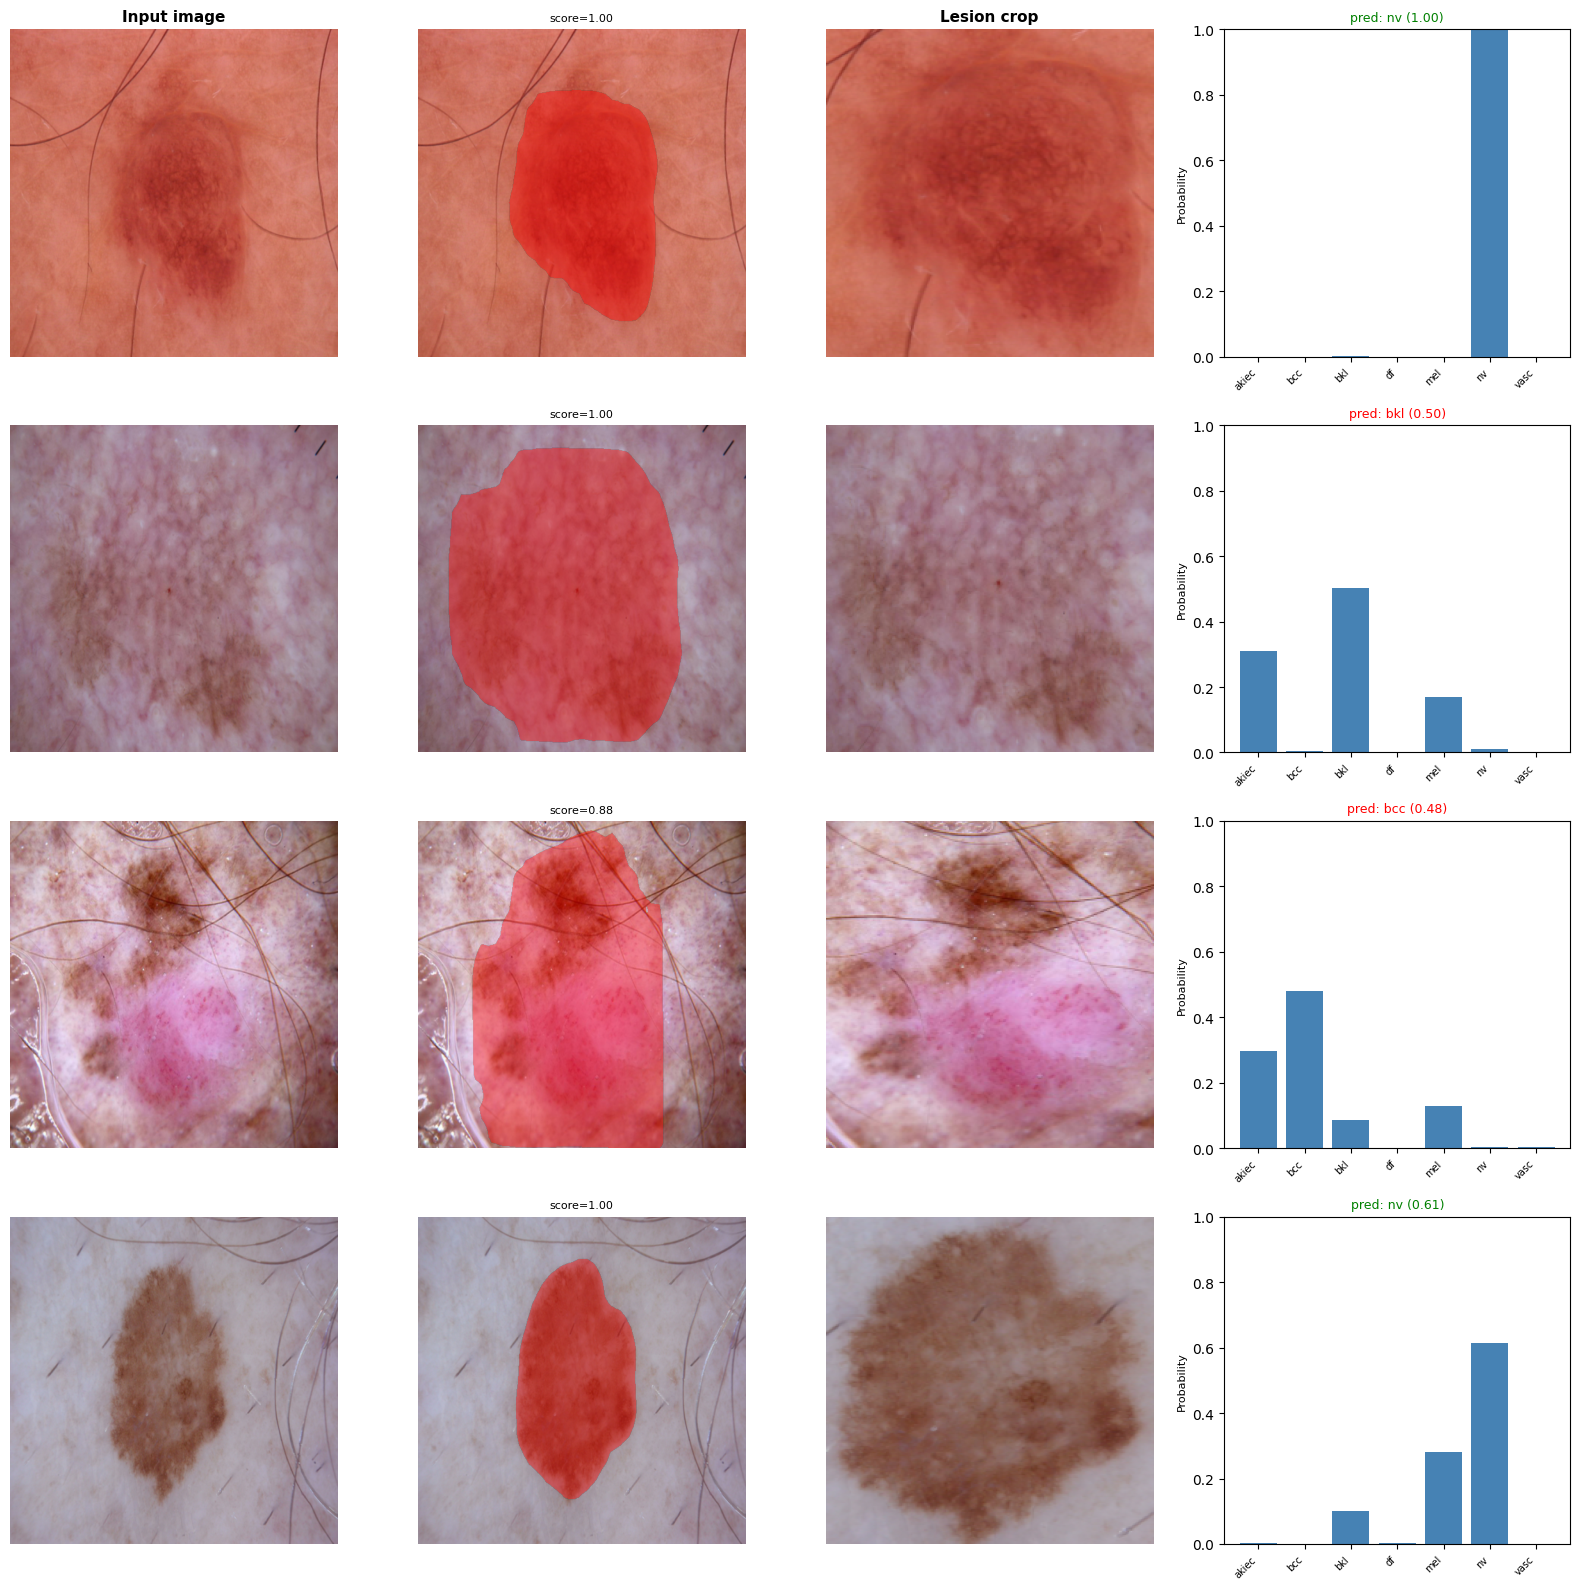

In [12]:
@torch.no_grad()
def collect_pipeline_results(
    pipeline: ISICPipeline,
    dataset:  HAM10000PipelineDataset,
    n:        int,
) -> list[dict]:
    """
    Run the pipeline on the first n images and collect results for visualisation.

    Args:
        pipeline: Instantiated ISICPipeline.
        dataset:  HAM10000PipelineDataset.
        n:        Number of images to process.

    Returns:
        List of dicts with keys: image, gt_label, result.
    """
    records = []
    for idx in range(min(n, len(dataset))):
        image, gt_label = dataset[idx]
        result = pipeline.predict(image)
        records.append({
            "image":    image,
            "gt_label": gt_label,
            "result":   result,
        })
    return records


def visualise_pipeline_outputs(
    records:   list[dict],
    n:         int = 4,
    save_path: Path | None = None,
) -> None:
    """
    Visualise n pipeline outputs, one per row.

    Columns: input image | mask overlay | lesion crop | class probabilities.

    Args:
        records:   Output of collect_pipeline_results.
        n:         Number of rows to display.
        save_path: If provided, save the figure at 150 dpi.
    """
    n = min(n, len(records))
    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    col_titles = ["Input image", "Mask overlay", "Lesion crop", "Prediction"]
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=11, fontweight="bold")

    for row, rec in enumerate(records[:n]):
        image    = rec["image"].permute(1, 2, 0).numpy().clip(0, 1)
        gt_label = rec["gt_label"]
        result   = rec["result"]

        axes[row, 0].imshow(image)
        axes[row, 0].set_ylabel(
            f"GT: {CLASSES[gt_label]}", fontsize=9, rotation=0,
            labelpad=80, va="center",
        )

        axes[row, 1].imshow(image)
        if not result.detection_failed:
            mask_overlay = np.zeros((*result.mask.shape, 4), dtype=np.float32)
            mask_overlay[result.mask] = [1.0, 0.0, 0.0, 0.4]
            axes[row, 1].imshow(mask_overlay)
        axes[row, 1].set_title(
            f"score={result.score:.2f}" if not result.detection_failed else "no detection",
            fontsize=8,
        )

        if result.crop is not None:
            axes[row, 2].imshow(result.crop.permute(1, 2, 0).numpy().clip(0, 1))
        else:
            axes[row, 2].text(
                0.5, 0.5, "detection failed", ha="center", va="center",
                transform=axes[row, 2].transAxes, fontsize=9,
            )
            axes[row, 2].set_facecolor("#f0f0f0")

        if result.class_probabilities is not None:
            pred_class = CLASSES[result.class_label]
            confidence = result.class_probabilities[result.class_label]
            correct    = result.class_label == gt_label
            color      = "green" if correct else "red"
            axes[row, 3].bar(CLASSES, result.class_probabilities, color="steelblue")
            axes[row, 3].set_ylim(0, 1)
            axes[row, 3].set_ylabel("Probability", fontsize=8)
            axes[row, 3].set_title(
                f"pred: {pred_class} ({confidence:.2f})", fontsize=9, color=color,
            )
        else:
            axes[row, 3].text(
                0.5, 0.5, "detection failed", ha="center", va="center",
                transform=axes[row, 3].transAxes, fontsize=9,
            )
            axes[row, 3].set_facecolor("#f0f0f0")

        for ax in axes[row, :3]:
            ax.axis("off")
        axes[row, 3].set_xticks(range(len(CLASSES)))
        axes[row, 3].set_xticklabels(CLASSES, rotation=45, ha="right", fontsize=7)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved to {save_path}")
    plt.show()


vis_records = collect_pipeline_results(pipeline, pipeline_dataset, n=CFG["n_visualise"])
visualise_pipeline_outputs(
    vis_records, n=CFG["n_visualise"],
    save_path=Path("/kaggle/working") / "pipeline_outputs.png",
)

## 7. Failure case analysis

In [14]:
@torch.no_grad()
def analyse_failures(
    pipeline: ISICPipeline,
    dataset:  HAM10000PipelineDataset,
) -> None:
    """
    Categorise failure modes across the evaluation set.

    Without segmentation ground truth, failure categories are:
      - Detection failure: no detection above score_threshold.
      - Classification failure given detection: predicted class is wrong.
      - Full success: detection succeeded and predicted class is correct.
    """
    n_detection_fail = 0
    n_cls_fail       = 0
    n_success        = 0

    for image, gt_label in torch.utils.data.DataLoader(
        dataset, batch_size=1, shuffle=False, num_workers=2,
    ):
        result       = pipeline.predict(image[0])
        gt_label_int = int(gt_label.item())

        if result.detection_failed:
            n_detection_fail += 1
        elif result.class_label != gt_label_int:
            n_cls_fail += 1
        else:
            n_success += 1

    n_total = n_detection_fail + n_cls_fail + n_success
    print(f"Failure analysis over {n_total} images:")
    print(f"  Detection failure:                 {n_detection_fail:3d} ({100*n_detection_fail/n_total:.1f}%)")
    print(f"  Classification failure (detected): {n_cls_fail:3d} ({100*n_cls_fail/n_total:.1f}%)")
    print(f"  Full success:                      {n_success:3d} ({100*n_success/n_total:.1f}%)")


analyse_failures(pipeline, pipeline_dataset)

Failure analysis over 50 images:
  Detection failure:                   0 (0.0%)
  Classification failure (detected):  15 (30.0%)
  Full success:                       35 (70.0%)
